<a href="https://colab.research.google.com/github/siddhartha-sai-17/Machine_Learning/blob/main/RandomForestRegressor_DecisionTreeRegressor(house_Dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving house_data.csv to house_data.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('house_data.csv')

In [5]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [6]:
X = df.drop('price',axis=1)
y = df['price']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [9]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [10]:
df = pd.get_dummies(df,drop_first=True)

In [11]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,False,False,False,False,False,False,False,False,False,False
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,False,False,False
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,False,False,False
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,False,False,False
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,False,False,False


In [19]:
print(df.dtypes)


price                float64
bedrooms             float64
bathrooms            float64
sqft_living            int64
sqft_lot               int64
                      ...   
statezip_WA 98188       bool
statezip_WA 98198       bool
statezip_WA 98199       bool
statezip_WA 98288       bool
statezip_WA 98354       bool
Length: 4725, dtype: object


In [25]:
X = X.apply(lambda col: col.astype(int) if col.dtype == "bool" else col)


In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
import pandas as pd

# Reload dataset from scratch
df = pd.read_csv("house_data.csv")

# Show columns
print("Original columns:", df.columns)

# Drop date column
df = df.drop(columns=["date"])

print("After dropping date:", df.columns)

# Separate target
X = df.drop("price", axis=1)
y = df["price"]

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# Convert bool to int
X = X.apply(lambda col: col.astype(int) if col.dtype == "bool" else col)

# Final check: NO object columns should exist
print("\nRemaining object columns:")
print(X.select_dtypes(include="object").columns)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(max_depth=8, random_state=42)

dt.fit(X_train, y_train)

print("✅ Model trained successfully!")


Original columns: Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')
After dropping date: Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country'],
      dtype='object')

Remaining object columns:
Index([], dtype='object')
✅ Model trained successfully!


In [37]:
y_pred = dt.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Mean squared error: 991696407571.15
Coefficient of determination: 0.03


In [38]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, random_state=42)

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Results")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 :", r2_score(y_test, y_pred_rf))


Random Forest Results
MSE: 969125844929.4678
R2 : 0.049733467841010515


In [32]:
from sklearn.metrics import mean_squared_error,r2_score
rf_pred = rf.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, rf_pred))
print("Coefficient of determination: %.2f" % r2_score(y_test, rf_pred))

Mean squared error: 973230817550.79
Coefficient of determination: 0.05


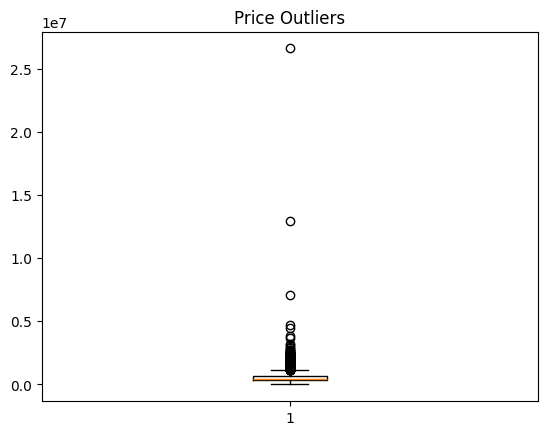

In [40]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df["price"])
plt.title("Price Outliers")
plt.show()


In [49]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) & (df["price"] <= upper)]

print("Remaining rows:", len(df))


Remaining rows: 4218


In [42]:
Q1 = df["sqft_living"].quantile(0.25)
Q3 = df["sqft_living"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["sqft_living"] >= lower) & (df["sqft_living"] <= upper)]


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))


MSE: 967501791790.1094
R2 : 0.05132591669876685


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


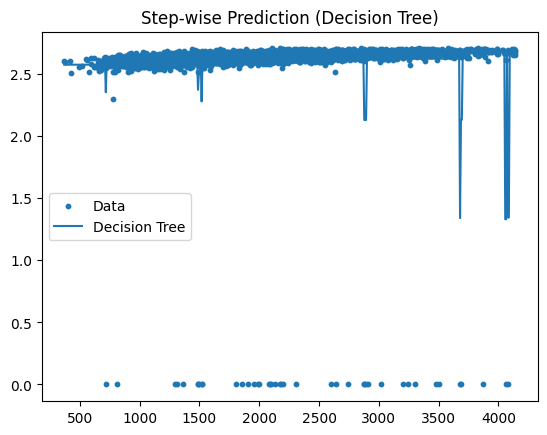

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Use only sqft_living for 1D visualization
X1 = df[["sqft_living"]]
y1 = df["price"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train1, y_train1)

# Create smooth input
X_range = np.linspace(X1.min(), X1.max(), 500).reshape(-1,1)
y_pred_tree = dt.predict(X_range)

plt.figure()
plt.scatter(X1, y1, s=10, label="Data")
plt.plot(X_range, y_pred_tree, label="Decision Tree")
plt.title("Step-wise Prediction (Decision Tree)")
plt.legend()
plt.show()


In [47]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=20, n_estimators=300, random_state=42)